### 导入库

In [1]:
!pip install keras-core --upgrade
!pip install -q keras-nlp --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.2 MB/s eta 0:00:0000:010:01


In [2]:
import os
os.environ['KERAS_BACKEND']='tensorflow'
import pandas as pd
import keras_core as keras
import numpy as np
import keras_nlp#开箱即用的预训练模型（BERT）和tokenizer
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print('Tensorflow version:',tf.__version__)
print('KerasNLP version:',keras_nlp.__version__)

Using TensorFlow backend
Tensorflow version: 2.20.0
KerasNLP version: 0.29.1


### 读取数据并查看

In [3]:
df_train=pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
df_test=pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')
print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage={:.2f}.MB'.format(df_train.memory_usage().sum()/1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))

Training Set Shape = (7613, 5)
Training Set Memory Usage=0.29.MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


In [4]:
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
df_test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
df_train['length']=df_train['text'].apply(lambda x:len(x))
df_test['length']=df_test['text'].apply(lambda x:len(x))

print('Train length stat')
print(df_train["length"].describe())
print()
print('Test length stat')
print(df_test['length'].describe())

Train length stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test length stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


### 预处理数据

定义超参数

In [7]:
BATCH_SIZE=32
NUM_TRAININIG_EXAMPLES=df_train.shape[0]
TRAIN_SPLIT=0.8#数据集切分比例
VAL_SPLIT=0.2
AUTO=tf.data.experimental.AUTOTUNE#自动监控CPU和GPU，决定使用多少线程去读取和预处理数据
EPOCHS=2
STEPS_PER_EPOCH=int(NUM_TRAININIG_EXAMPLES)*TRAIN_SPLIT//BATCH_SIZE

划分数据集

In [8]:
from sklearn.model_selection import train_test_split

X=df_train['text']
y=df_train['target']
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=VAL_SPLIT,random_state=42)#参数顺序不能错

X_test=df_test['text']

从Keras NLP中载入DistilBERT model

Text在input到BERT前需要transformed to numerical token ids同时arranged in several Tensors

BertClassifier Model可以配置预处理层；一旦配置，模型就会在执行 `fit()`、`predict()` 和 `evaluate()` 时自动对原始输入进行预处理。当使用 `from_preset()` 创建模型时，系统默认会启用此功能。

模型解释：
该模型学习的是 BERT 的蒸馏（近似）版本，在仅使用一半参数的情况下保留了 97% 的性能（[论文](https://arxiv.org/abs/1910.01108)）。

与 `bert-base-uncased` 相比，它的参数量减少了 40%，运行速度提升了 60%，同时在 GLUE 语言理解基准测试中保留了超过 95% 的 BERT 性能。

具体而言，该模型去除了 token-type embedding（标记类型嵌入）和 pooler（池化层），并且仅保留了 Google BERT 一半数量的层。

In [9]:
preset="distil_bert_base_en_uncased"
#将文本转化为tensor，截断or填充到160个token，最后给处理器取个名字
preprocessor=keras_nlp.models.DistilBertPreprocessor.from_preset(preset,sequence_length=160,name='preprocessor_4_tweets')


I0000 00:00:1783017672.403142      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


classifier的作用：
Input Text->Preprocessor->DistilBERT Encoder（Transformer）->[CLS] token 向量->Dense 全连接层->Softmax

In [10]:
classifier=keras_nlp.models.DistilBertClassifier.from_preset(preset,preprocessor=preprocessor,num_classes=2)
classifier.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

### 训练模型，finetunning BERT

In [11]:
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(1e-5),
    metrics=["accuracy"]
)
history=classifier.fit(
    x=X_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val,y_val),
)

Epoch 1/2


I0000 00:00:1783017727.119261     117 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


191/191 ━━━━━━━━━━━━━━━━━━━━ 126s 411ms/step - accuracy: 0.7762 - loss: 0.4945 - val_accuracy: 0.8490 - val_loss: 0.3908
Epoch 2/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 48s 252ms/step - accuracy: 0.8488 - loss: 0.3716 - val_accuracy: 0.8457 - val_loss: 0.3838


In [31]:
def displayConfusionMatrix(y_true,y_pred,dataset):
    disp=ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),
        display_labels=['Not Disaster','Disaster'],
        cmap=plt.cm.Blues
    )
    tn,fp,fn,tp=confusion_matrix(y_true,np.argmax(y_pred,axis=1)).ravel()
    f1_score=tp/(tp+((fn+fp)/2))

    disp.ax_.set_title("Confusion Matrix on " + dataset + " Dataset -- F1 Score: " + str(f1_score.round(2)))

191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step


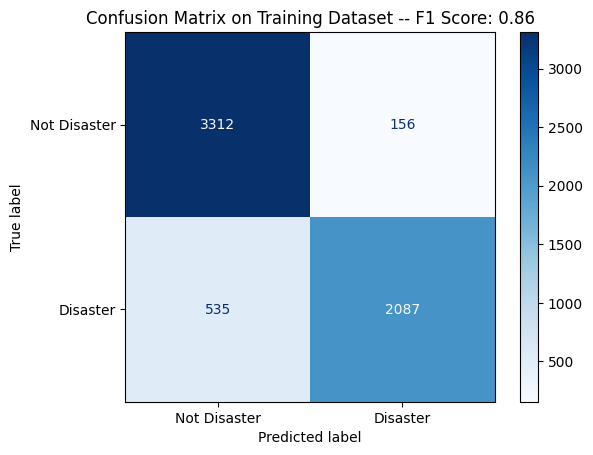

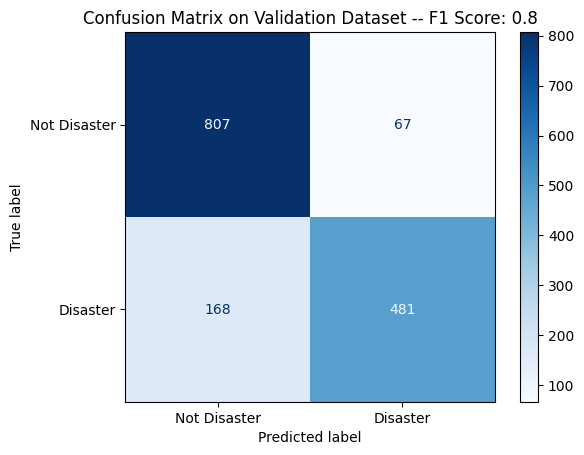

In [32]:
y_pred_train=classifier.predict(X_train)
displayConfusionMatrix(y_train,y_pred_train,"Training")

y_pred_val=classifier.predict(X_val)
displayConfusionMatrix(y_val,y_pred_val,"Validation")

In [33]:
sample_submission = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/sample_submission.csv")
sample_submission.head()

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


In [34]:
sample_submission["target"] = np.argmax(classifier.predict(X_test), axis=1)
sample_submission.describe()

102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step


,id,target
count,3263.000000,3263.000000
mean,5427.152927,0.354582
std,3146.427221,0.478460
min,0.000000,0.000000
25%,2683.000000,0.000000
50%,5500.000000,0.000000
75%,8176.000000,1.000000
max,10875.000000,1.000000


In [35]:
sample_submission.to_csv("submission.csv", index=False)